In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.metrics import mean_squared_error, r2_score

In [8]:
data=load_diabetes()

In [9]:
x=data.data
y=data.target

In [11]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [12]:
lin=LinearRegression()
lin.fit(x_train,y_train)

LinearRegression()

In [15]:
ridge_cv=GridSearchCV(
    Ridge(),
    {"alpha":[.01,.1,1,10,100]},
    cv=5,
    scoring="neg_mean_squared_error"
)
ridge_cv.fit(x_train,y_train)
ridge=ridge_cv.best_estimator_

In [16]:
lasso_cv=GridSearchCV(
    Lasso(max_iter=10000),
    {"alpha":[.01,.1,1,10,100]},
    cv=5,
    scoring="neg_mean_squared_error"
)
lasso_cv.fit(x_train,y_train)
lasso=lasso_cv.best_estimator_

In [17]:
rows=[]

In [18]:
models={
    "Linear":lin,
    "Ridge":ridge,
    "Lasso":lasso
}

In [19]:
for name,model in models.items():
  y_pred=model.predict(x_test)
  rows.append([
      name,
      mean_squared_error(y_test,y_pred),
      r2_score(y_test,y_pred)
  ])


In [20]:
print("Best Ridge alpha:",ridge_cv.best_params_)
print("Best Lasso alpha:",lasso_cv.best_params_)


Best Ridge alpha: {'alpha': 0.1}
Best Lasso alpha: {'alpha': 0.1}


In [22]:
print(pd.DataFrame(rows,columns=["Model","MSE","R2"]))

    Model          MSE        R2
0  Linear  2900.193628  0.452603
1   Ridge  2856.486888  0.460852
2   Lasso  2798.193485  0.471855


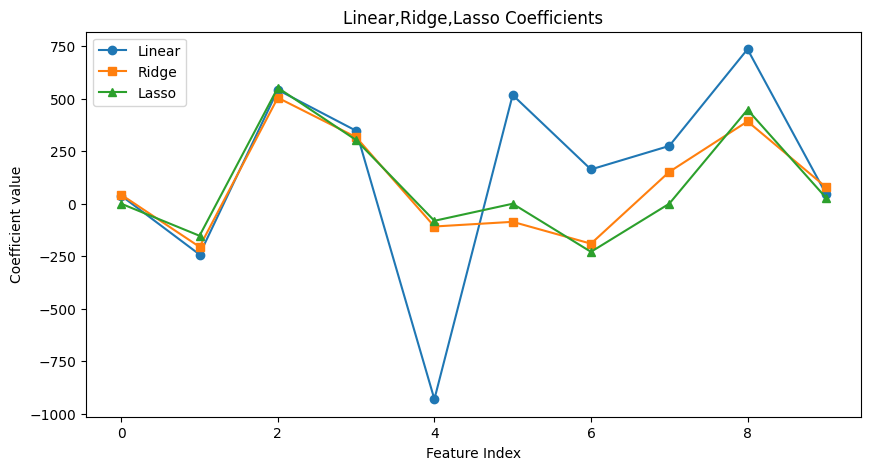

In [25]:
plt.figure(figsize=(10,5))
plt.plot(lin.coef_,"o-",label="Linear")
plt.plot(ridge.coef_,"s-",label="Ridge")
plt.plot(lasso.coef_,"^-",label="Lasso")
plt.xlabel("Feature Index")
plt.ylabel("Coefficient value")
plt.title("Linear,Ridge,Lasso Coefficients")
plt.legend()
plt.show()